# Lab Assignment 1 - kNN Voice Classification
## JS05 - Classification 1

**Name:** Tiara Febrianie  
**NIM:** 244107020097

### Objective
Build a k-nearest neighbors (kNN) model to classify voice samples as male or female, identify the most useful features, and determine the best value of k.

## 1. Load and Inspect the Dataset

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

voice = pd.read_csv("voice.csv")
voice.head()

Feature data:
 [[112 139]
 [179 210]
 [ 83  71]
 [182 265]
 [105  78]
 [ 67  43]
 [ 36  54]
 [ 20  70]
 [122  70]
 [250  83]
 [ 50 142]
 [206 110]
 [115  84]
 [124  66]
 [150  85]
 [ 16  73]
 [ 46 113]
 [ 26  80]
 [ 18 114]
 [211 154]
 [ 53  66]
 [ 93 109]
 [175 172]
 [ 80  85]
 [111 125]
 [115 105]
 [ 66  92]
 [160  85]
 [ 53 106]
 [122  85]]
Labels:
 [0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


## 2. Data Exploration

In [ ]:
print("Dataset shape:", voice.shape)
print("Missing values:", voice.isna().sum().sum())
print("Class distribution:\n", voice["label"].value_counts())
voice.describe().T

,Feature 1,Feature 2,Label
0,112,139,0
1,179,210,0
2,83,71,0
3,182,265,0
4,105,78,0


In [ ]:
feature_columns = voice.drop(columns="label").columns.tolist()
print("Number of features:", len(feature_columns))
print(feature_columns)

,Feature 1,Feature 2,Label
0,112,139,Class B
1,179,210,Class B
2,83,71,Class B
3,182,265,Class B
4,105,78,Class B


In [ ]:
X = voice[feature_columns]
y = voice["label"].map({"male": 0, "female": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

## 4. Feature Selection Experiment

Each feature is evaluated independently with a standardized kNN model and 5-fold stratified cross-validation. The five highest-scoring features will be used for the k experiment.

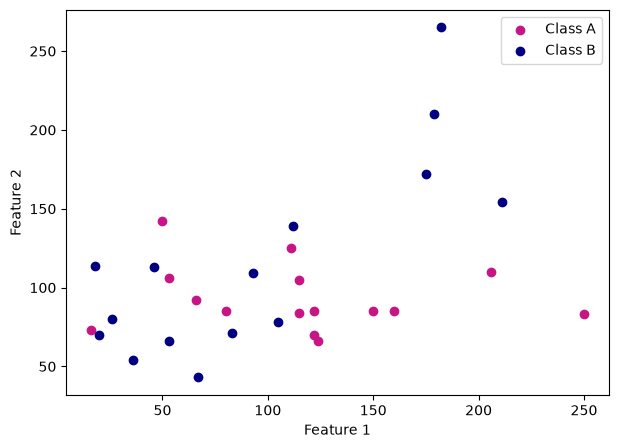

In [ ]:
feature_scores = []
for feature in feature_columns:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
    ])
    scores = cross_val_score(model, X[[feature]], y, cv=cv, scoring="accuracy")
    feature_scores.append({
        "Feature": feature,
        "Mean CV Accuracy": scores.mean(),
        "Std CV Accuracy": scores.std(),
    })

feature_results = (
    pd.DataFrame(feature_scores)
    .sort_values("Mean CV Accuracy", ascending=False)
    .reset_index(drop=True)
)
selected_features = feature_results.head(5)["Feature"].tolist()
print("Selected features:", selected_features)
feature_results

In [ ]:
# Plot feature-selection results

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(
    feature_results["Feature"].iloc[::-1],
    feature_results["Mean CV Accuracy"].iloc[::-1],
    color="steelblue",
)
plt.xlabel("Mean 5-Fold Cross-Validation Accuracy")
plt.ylabel("Feature")
plt.title("Individual Feature Performance")
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

Training accuracy (Multinomial): 0.809524
Test accuracy (Multinomial): 0.333333


In [ ]:
# 5. Find the Best k Value

The selected features are evaluated for `k` values from 1 to 20 using 5-fold stratified cross-validation. The value with the highest mean accuracy is selected.

In [ ]:
k_results = []
for k in range(1, 21):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    scores = cross_val_score(model, X[selected_features], y, cv=cv, scoring="accuracy")
    k_results.append({"k": k, "Mean CV Accuracy": scores.mean(), "Std CV Accuracy": scores.std()})

k_results = pd.DataFrame(k_results)
best_k = int(k_results.loc[k_results["Mean CV Accuracy"].idxmax(), "k"])
print("Best k:", best_k)
k_results

Training accuracy (Gaussian): 0.857143
Test accuracy (Gaussian): 0.444444


In [ ]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k)),
])
final_model.fit(X_train[selected_features], y_train)

y_train_pred = final_model.predict(X_train[selected_features])
y_test_pred = final_model.predict(X_test[selected_features])

print("Training accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification report:\n", classification_report(y_test, y_test_pred, target_names=["male", "female"]))

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(k_results["k"], k_results["Mean CV Accuracy"], marker="o", color="darkgreen")
plt.axvline(best_k, linestyle="--", color="crimson", label=f"Best k = {best_k}")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Mean 5-Fold Cross-Validation Accuracy")
plt.title("k Value vs Cross-Validation Accuracy")
plt.xticks(range(1, 21))
plt.ylim(0.7, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

,Model,Training Accuracy,Test Accuracy
0,MultinomialNB,0.809524,0.333333
1,GaussianNB,0.857143,0.444444


## Conclusion

The feature experiment ranks individual voice features using 5-fold stratified cross-validation. The five highest-scoring features are selected for the final model. The best `k` is chosen from the cross-validation curve, and the final kNN model is evaluated on a separate stratified test set. This provides a data-driven answer to both the feature-selection and parameter-selection questions.